In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('gold_related_data_cleaned.csv')
# Check for missing values
print(df.isnull().sum())


Date         0
Gold         0
S&P500       0
Nasdaq       0
DowJones     0
CrudeOil     0
USD_Index    0
dtype: int64


In [9]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df.head()

/var/folders/zk/5r6d8__90mbfg5x8ftvmmy140000gp/T/ipykernel_37643/2209811501.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


,Gold,S&P500,Nasdaq,DowJones,CrudeOil,USD_Index
Date,,,,,,
2015-01-02,1186.0,2058.2000,4726.8101,17832.9902,52.69,91.08
2015-01-05,1203.9,2020.5800,4652.5698,17501.6504,50.04,91.38
2015-01-06,1219.3,2002.6100,4592.7402,17371.6406,47.93,91.50
2015-01-07,1210.6,2025.9000,4650.4702,17584.5195,48.65,91.89
2015-01-08,1208.4,2062.1399,4736.1899,17907.8691,48.79,92.37


In [5]:
df.columns
df.dtypes

Date          object
Gold         float64
S&P500       float64
Nasdaq       float64
DowJones     float64
CrudeOil     float64
USD_Index    float64
dtype: object

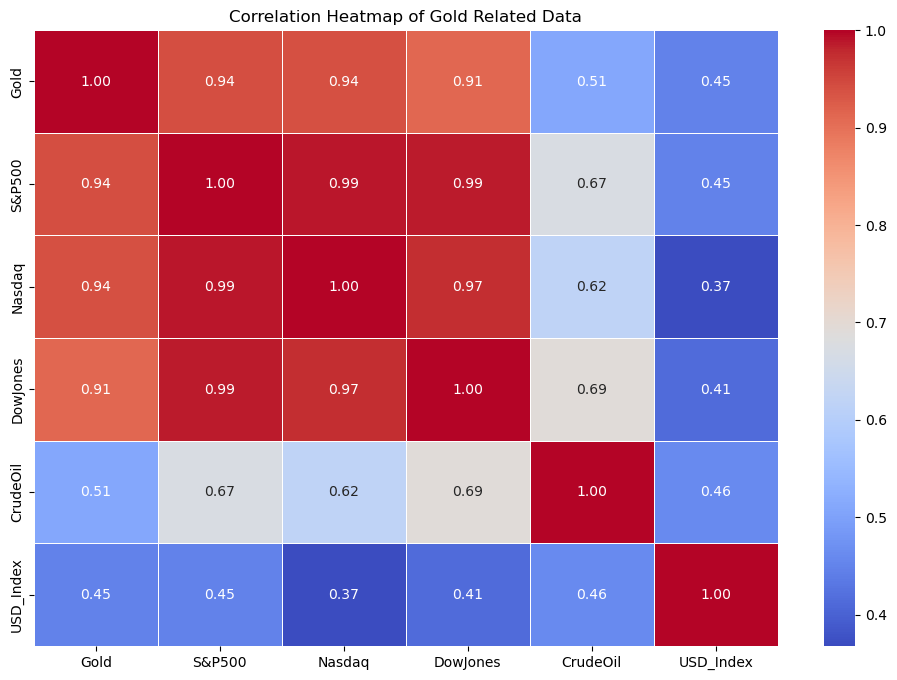

In [10]:
# heatmap of df 
import seaborn as sns
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)
plt.title("Correlation Heatmap of Gold Related Data")
plt.show()

Split & Modeling (ARIMA)

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from keras.models import Sequential
from keras.layers import LSTM, Dense


In [14]:
gold_series = df['Gold'].copy()
train_size = int(len(gold_series) * 0.8)
train, test = gold_series[:train_size], gold_series[train_size:]


Arima

In [15]:
# Auto ARIMA model selection
arima_model = auto_arima(train, seasonal=False, stepwise=True, trace=True, error_action='ignore', suppress_warnings=True)

# Fit model
arima_fitted = arima_model.fit(train)

# Predict on test set
arima_pred = arima_fitted.predict(n_periods=len(test))


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=16455.570, Time=0.96 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16451.802, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16452.666, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16452.654, Time=0.07 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16450.755, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16454.636, Time=0.20 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 1.303 seconds


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


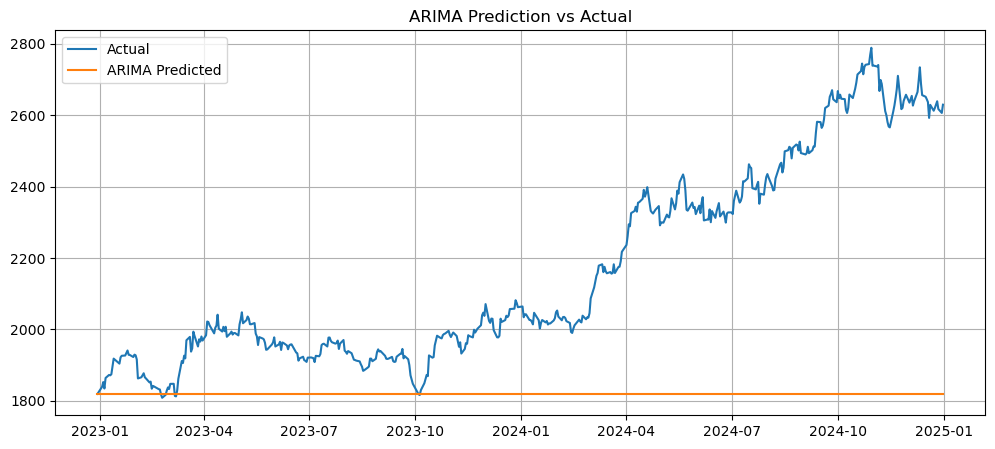

📊 ARIMA Evaluation Metrics:
MAE: 347.210931610338
RMSE: 444.3042678372686
R² Score: -1.5658362366345213


In [16]:
from sklearn.metrics import r2_score

plt.figure(figsize=(12, 5))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, arima_pred, label='ARIMA Predicted')
plt.legend()
plt.title("ARIMA Prediction vs Actual")
plt.grid()
plt.show()

print("📊 ARIMA Evaluation Metrics:")
print("MAE:", mean_absolute_error(test, arima_pred))
print("RMSE:", np.sqrt(mean_squared_error(test, arima_pred)))
print("R² Score:", r2_score(test, arima_pred))


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


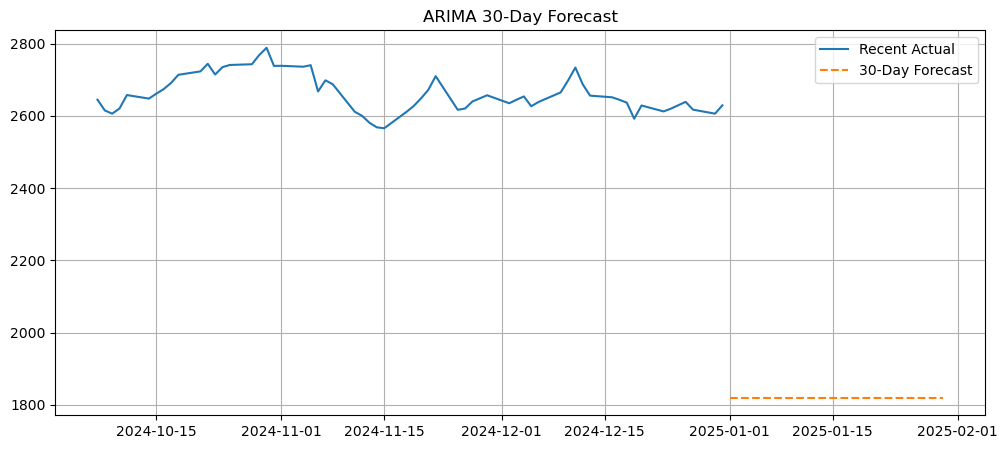

In [17]:
future_forecast = arima_fitted.predict(n_periods=30)

plt.figure(figsize=(12, 5))
plt.plot(df.index[-60:], df['Gold'].values[-60:], label="Recent Actual")
future_dates = pd.date_range(df.index[-1] + pd.Timedelta(days=1), periods=30)
plt.plot(future_dates, future_forecast, label="30-Day Forecast", linestyle='--')
plt.legend()
plt.title("ARIMA 30-Day Forecast")
plt.grid()
plt.show()


LSTM Implementation

LSTM Using the entire dataset

In [18]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense

# Load cleaned DataFrame again (assuming it's the same as 'df')
df = pd.read_csv('gold_related_data_cleaned.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Scale Gold prices
scaler = MinMaxScaler()
gold_scaled = scaler.fit_transform(df[['Gold']])

# Create sequences
look_back = 30
X, y = [], []
for i in range(look_back, len(gold_scaled)):
    X.append(gold_scaled[i-look_back:i, 0])
    y.append(gold_scaled[i, 0])
X, y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# Train final LSTM model on full dataset
final_model = Sequential()
final_model.add(LSTM(50, return_sequences=True, input_shape=(look_back, 1)))
final_model.add(LSTM(50))
final_model.add(Dense(1))
final_model.compile(optimizer='adam', loss='mse')
final_model.fit(X, y, epochs=20, batch_size=32, verbose=0)

# Forecast next 30 days
def forecast_lstm(model, initial_sequence, steps):
    current_seq = initial_sequence.copy()
    predictions = []
    for _ in range(steps):
        next_pred = model.predict(current_seq.reshape(1, look_back, 1), verbose=0)
        predictions.append(next_pred[0, 0])
        current_seq = np.append(current_seq[1:], next_pred)
    return scaler.inverse_transform(np.array(predictions).reshape(-1, 1))

# Use the last look_back days for forecasting
last_sequence = gold_scaled[-look_back:]
lstm_future_preds = forecast_lstm(final_model, last_sequence, 30)

# Create date range for next 30 days
future_dates = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=30, freq='B')

# Combine forecast with dates
lstm_forecast_table = pd.DataFrame({
    'Date': future_dates,
    'Predicted_Gold_Price': lstm_future_preds.flatten()
})

lstm_forecast_table.head()


/var/folders/zk/5r6d8__90mbfg5x8ftvmmy140000gp/T/ipykernel_37643/4092256500.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])
/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


,Date,Predicted_Gold_Price
0,2025-01-01,2622.269287
1,2025-01-02,2624.442871
2,2025-01-03,2627.075439
3,2025-01-06,2630.022461
4,2025-01-07,2633.176758


LSTM Using Train-Test Split & Hypertuning

In [31]:
# Load the data again if needed
df = pd.read_csv('gold_related_data_cleaned.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Scale the 'Gold' prices
scaler = MinMaxScaler()
gold_scaled = scaler.fit_transform(df[['Gold']])

# Create sequences for LSTM
look_back = 30
X, y = [], []
for i in range(look_back, len(gold_scaled)):
    X.append(gold_scaled[i-look_back:i, 0])
    y.append(gold_scaled[i, 0])
X, y = np.array(X), np.array(y)

# Split into training and test datasets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Reshape input for LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))


/var/folders/zk/5r6d8__90mbfg5x8ftvmmy140000gp/T/ipykernel_37643/2773555735.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [32]:
# Build and train the LSTM model
final_model = Sequential()
final_model.add(LSTM(50, return_sequences=True, input_shape=(look_back, 1)))
final_model.add(LSTM(50))
final_model.add(Dense(1))
final_model.compile(optimizer='adam', loss='mse')
final_model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [33]:
# Predict on the test set
y_pred = final_model.predict(X_test)

# Inverse transform the scaled predictions and test data
y_pred_actual = scaler.inverse_transform(y_pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r2 = r2_score(y_test_actual, y_pred_actual)

print("Evaluation Metrics for LSTM:")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R² Score: {r2}")


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Evaluation Metrics for LSTM:
Mean Absolute Error (MAE): 37.45087144153985
Root Mean Squared Error (RMSE): 49.953152806672676
R² Score: 0.9674308128204768


In [34]:
# Forecast the next 30 days
def forecast_lstm(model, initial_sequence, steps):
    current_seq = initial_sequence.copy()
    predictions = []
    for _ in range(steps):
        next_pred = model.predict(current_seq.reshape(1, look_back, 1), verbose=0)
        predictions.append(next_pred[0, 0])
        current_seq = np.append(current_seq[1:], next_pred)
    return scaler.inverse_transform(np.array(predictions).reshape(-1, 1))

# Use the last look_back days from the training set for forecasting
last_sequence = gold_scaled[-look_back:]
lstm_future_preds = forecast_lstm(final_model, last_sequence, 30)

# Create date range for next 30 days
future_dates = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=30, freq='B')

# Combine forecast with dates
lstm_forecast_table = pd.DataFrame({
    'Date': future_dates,
    'Predicted_Gold_Price': lstm_future_preds.flatten()
})

lstm_forecast_table.head()


,Date,Predicted_Gold_Price
0,2025-01-01,2538.406006
1,2025-01-02,2528.194824
2,2025-01-03,2512.769287
3,2025-01-06,2494.313965
4,2025-01-07,2474.172119


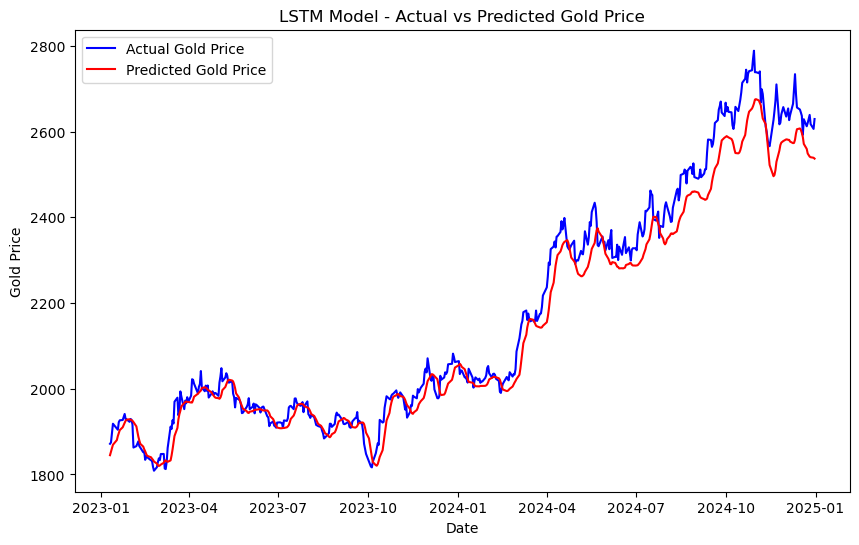

In [35]:
import matplotlib.pyplot as plt

# Plot actual vs predicted for the test data
plt.figure(figsize=(10,6))
plt.plot(df.index[-len(y_test_actual):], y_test_actual, label="Actual Gold Price", color='blue')
plt.plot(df.index[-len(y_pred_actual):], y_pred_actual, label="Predicted Gold Price", color='red')
plt.title('LSTM Model - Actual vs Predicted Gold Price')
plt.xlabel('Date')
plt.ylabel('Gold Price')
plt.legend()
plt.show()


Use Keras Tuner to Optimize Hyperparameters

In [43]:
import keras_tuner as kt
from tensorflow.keras import layers

# Function to build the model with hyperparameters
def build_model(hp):
    model = Sequential()
    
    # Tune the number of LSTM layers
    for i in range(hp.Int('num_layers', 1, 3)):  # Number of LSTM layers between 1 and 3
        model.add(LSTM(units=hp.Int('units_' + str(i), min_value=50, max_value=200, step=50),
                       return_sequences=True if i < hp.Int('num_layers', 1, 3) - 1 else False,
                       input_shape=(look_back, 1)))
        
    model.add(Dense(1))
    
    # Tune optimizer and learning rate
    model.compile(optimizer=hp.Choice('optimizer', ['adam', 'rmsprop']),
                  loss='mse', 
                  metrics=['mae'])
    
    return model

# Hyperparameter tuning with Keras Tuner
tuner = kt.Hyperband(build_model,
                     objective='val_loss',
                     max_epochs=10,
                     hyperband_iterations=2,
                     directory='hyperband_dir',
                     project_name='gold_price_lstm')

# Split the data for validation
X_train, X_val = X[:train_size], X[train_size:]
y_train, y_val = y[:train_size], y[train_size:]

# Fit the tuner
tuner.search(X_train, y_train, epochs=10, validation_data=(X_val, y_val))

# Get the best model
best_model = tuner.get_best_models(1)[0]

# Evaluate the best model
best_model.evaluate(X_val, y_val)

# Get the best hyperparameters
best_hyperparameters = tuner.get_best_hyperparameters(1)[0]
print(f"Best Hyperparameters: {best_hyperparameters}")


Reloading Tuner from hyperband_dir/gold_price_lstm/tuner0.json


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/opt/anaconda3/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.7219e-04 - mae: 0.0103 
Best Hyperparameters: <keras_tuner.src.engine.hyperparameters.hyperparameters.HyperParameters object at 0x318eda870>


Build the final Model using the best hyperparameters

In [44]:
# Rebuild the best model using the best hyperparameters
def build_best_model(hp):
    model = Sequential()
    num_layers = hp.get('num_layers')

    for i in range(num_layers):
        return_seq = True if i < num_layers - 1 else False
        units = hp.get(f'units_{i}')
        model.add(LSTM(units=units, return_sequences=return_seq, input_shape=(look_back, 1)))

    model.add(Dense(1))
    model.compile(optimizer=hp.get('optimizer'), loss='mse', metrics=['mae'])
    return model

# Build and train
final_model = build_best_model(best_hyperparameters)
final_model.fit(X, y, epochs=20, batch_size=32, verbose=0)


In [45]:
# Forecasting next 30 days
lstm_future_preds = forecast_lstm(final_model, last_sequence, 30)

# Create date range for next 30 business days
future_dates = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=30, freq='B')

# Combine forecast with dates
forecast_table = pd.DataFrame({
    'Date': future_dates,
    'Predicted_Gold_Price': lstm_future_preds.flatten()
})
forecast_table.head()

,Date,Predicted_Gold_Price
0,2025-01-01,2623.244873
1,2025-01-02,2625.878174
2,2025-01-03,2627.838623
3,2025-01-06,2629.263672
4,2025-01-07,2630.276123


In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))


val_preds = final_model.predict(X_val)
val_preds_rescaled = scaler.inverse_transform(val_preds)
y_val_rescaled = scaler.inverse_transform(y_val.reshape(-1, 1))

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_val_rescaled, val_preds_rescaled)
rmse = np.sqrt(mean_squared_error(y_val_rescaled, val_preds_rescaled))
r2 = r2_score(y_val_rescaled, val_preds_rescaled)

print("📊 Final Tuned LSTM Evaluation Metrics:")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R² Score: {r2}")


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
📊 Final Tuned LSTM Evaluation Metrics:
MAE: 22.22403539321869
RMSE: 28.664876151488123
R² Score: 0.9892753963356032


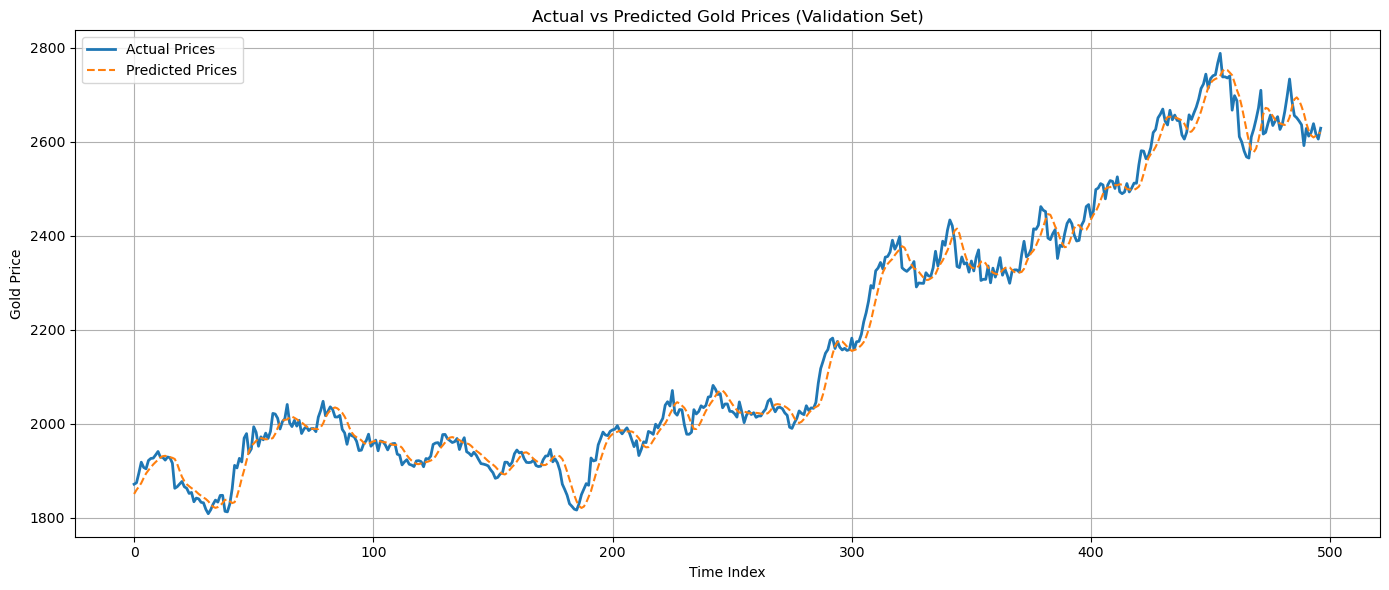

In [47]:
import matplotlib.pyplot as plt

# Plot actual vs predicted on validation data
plt.figure(figsize=(14, 6))
plt.plot(y_val_rescaled, label='Actual Prices', linewidth=2)
plt.plot(val_preds_rescaled, label='Predicted Prices', linestyle='--')
plt.title('Actual vs Predicted Gold Prices (Validation Set)')
plt.xlabel('Time Index')
plt.ylabel('Gold Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Create a function to take input from user for how many days wants to predict

In [48]:
def predict_future_prices(model, scaler, df, look_back=30, future_days=30):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    # Last sequence
    last_sequence = scaler.transform(df[['Gold']])[-look_back:]
    current_input = last_sequence.reshape(1, look_back, 1)

    predictions = []
    for _ in range(future_days):
        pred = model.predict(current_input, verbose=0)[0][0]
        predictions.append(pred)
        current_input = np.append(current_input[:, 1:, :], [[[pred]]], axis=1)

    # Inverse transform
    predictions_rescaled = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))

    # Create date range
    last_date = df.index[-1]
    future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=future_days, freq='B')

    # DataFrame
    result_df = pd.DataFrame({
        'Date': future_dates,
        'Predicted_Gold_Price': predictions_rescaled.flatten()
    })

    # Plot
    plt.figure(figsize=(14, 6))
    plt.plot(result_df['Date'], result_df['Predicted_Gold_Price'], color='orange', label='Predicted Gold Prices')
    plt.title(f'Predicted Gold Prices for Next {future_days} Business Days')
    plt.xlabel('Date')
    plt.ylabel('Gold Price')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return result_df


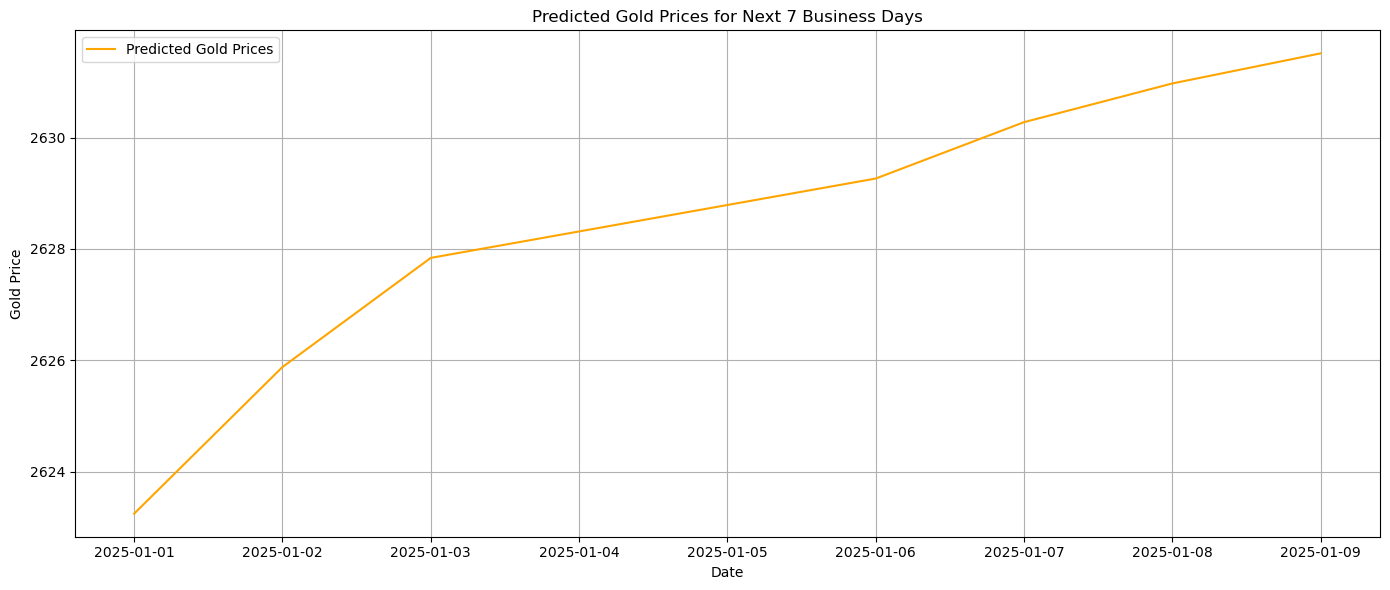

,Date,Predicted_Gold_Price
0,2025-01-01,2623.244873
1,2025-01-02,2625.878174
2,2025-01-03,2627.838623
3,2025-01-06,2629.263672
4,2025-01-07,2630.276123


In [49]:
# Ask user input
future_days = int(input("How many days of future gold price do you want to predict? "))
future_prices_df = predict_future_prices(final_model, scaler, df, future_days=future_days)
future_prices_df.head()
